In [1]:
from run_simulation import run_simulation, print_statistics
import simpy

# Run the simulation sequentially
num_permits = 6410
print("Running simulation with " + str(num_permits) + " permits...")
sim = run_simulation(
    num_permits=num_permits,
    random_seed=42,
    inter_arrival_time=0,
    sequential=True  # Changed to True for sequential processing
)

# Get and display statistics
stats = sim.get_statistics()
print_statistics(stats)

Running simulation with 6410 permits...

SIMULATION STATISTICS

Total Completed Permits: 6410
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   : 4682 (73.04%)
  CUSTOM_NON_LIKE               : 1103 (17.21%)
  PRE_APPROVED_LIKE             :  111 ( 1.73%)
  PRE_APPROVED_NON_LIKE         :   22 ( 0.34%)
  SELF_CERT_LIKE                :  390 ( 6.08%)
  SELF_CERT_NON_LIKE            :  102 ( 1.59%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     375.77 days
  Median:   391.41 days
  Std Dev:  140.90 days
  Min:       75.15 days
  Max:     2379.79 days

--------------------------------------------------------------------------------
PROCESSING TI

In [2]:
# Optional: Access individual permit data
print(f"\nFirst 5 completed permits:")
for permit in sim.completed_permits[:5]:
    total_time = permit.ready_for_construction - permit.created_at if permit.ready_for_construction else None
    print(f"  Permit {permit.permit_id} ({permit.segment.name}): "
          f"{total_time:.2f} days total, "
          f"{permit.public_works_rechecks} re-checks")



First 5 completed permits:
  Permit 1231 (PRE_APPROVED_LIKE): 75.15 days total, 1 re-checks
  Permit 289 (PRE_APPROVED_NON_LIKE): 79.58 days total, 1 re-checks
  Permit 49 (CUSTOM_LIKE): 80.72 days total, 0 re-checks
  Permit 591 (CUSTOM_LIKE): 84.10 days total, 1 re-checks
  Permit 838 (PRE_APPROVED_LIKE): 84.87 days total, 1 re-checks


Creating visualizations for 6410 permits...
  Creating stacked bar chart...
  Creating Gantt chart...
  Creating average time by stage chart...
  Creating time by segment chart...
  Creating time by segment chart (Like-for-like only)...
  Creating time by segment chart (Non-like-for-like only)...
  Creating total time by segment chart (box plot)...


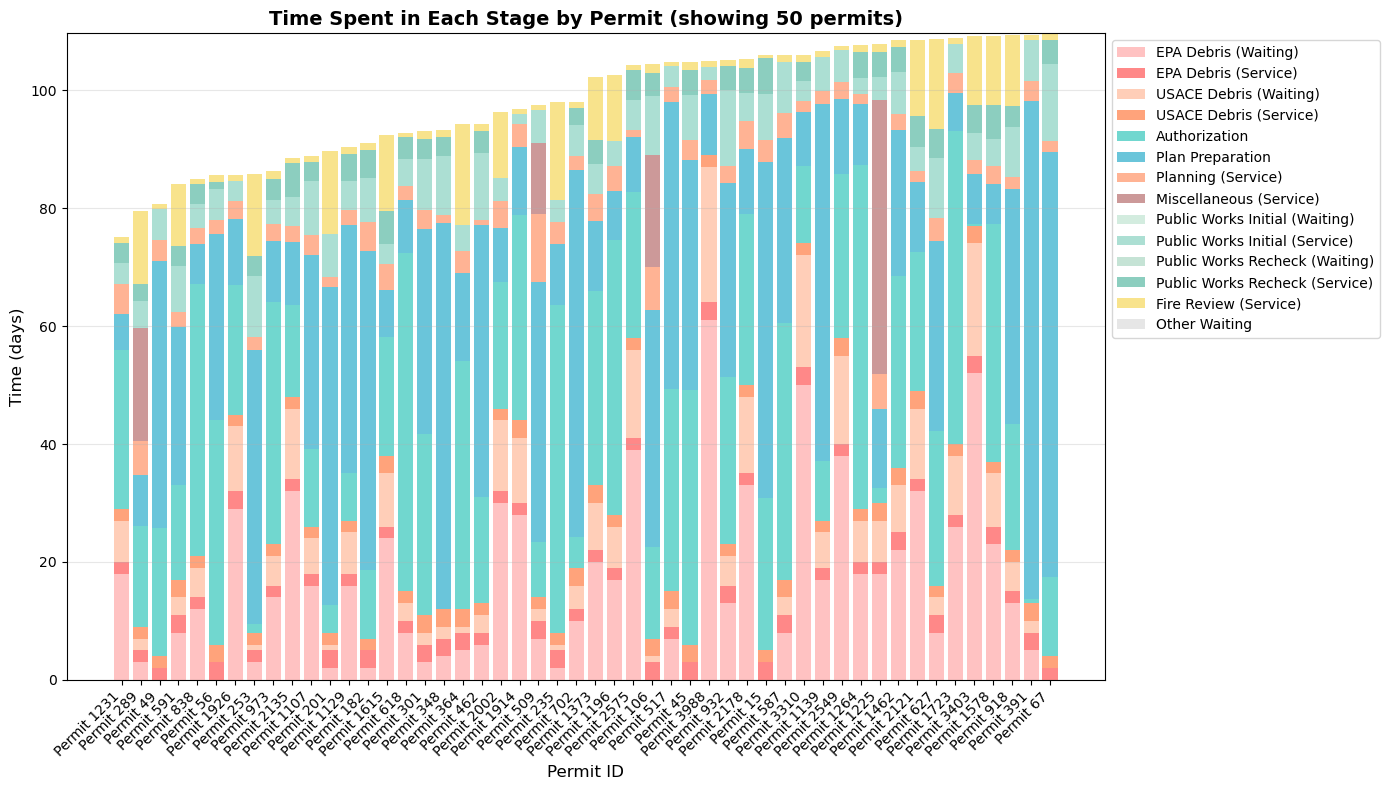

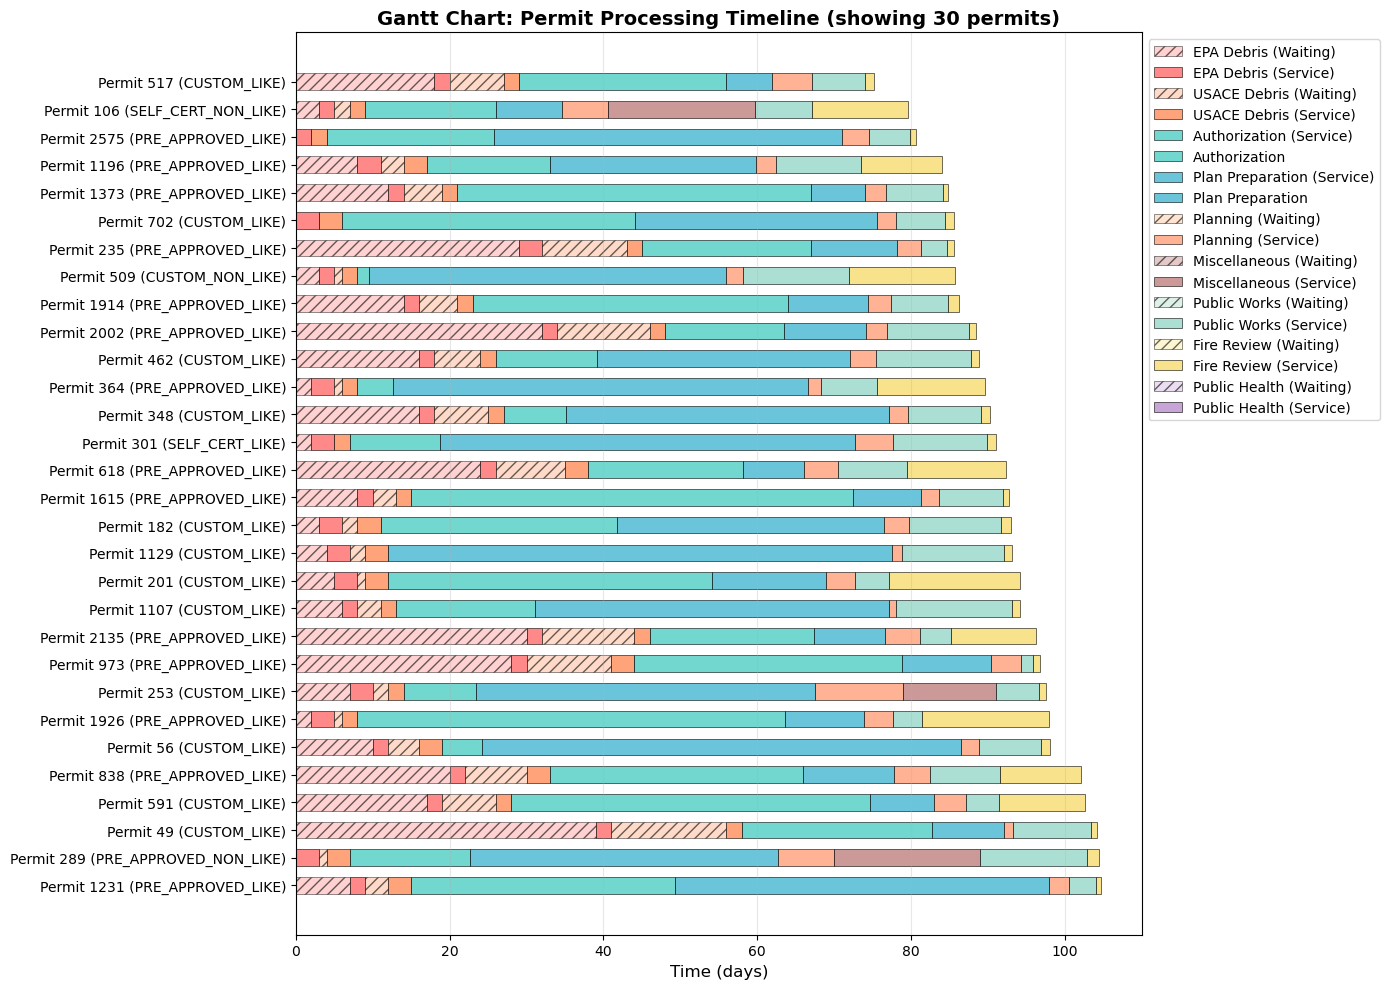

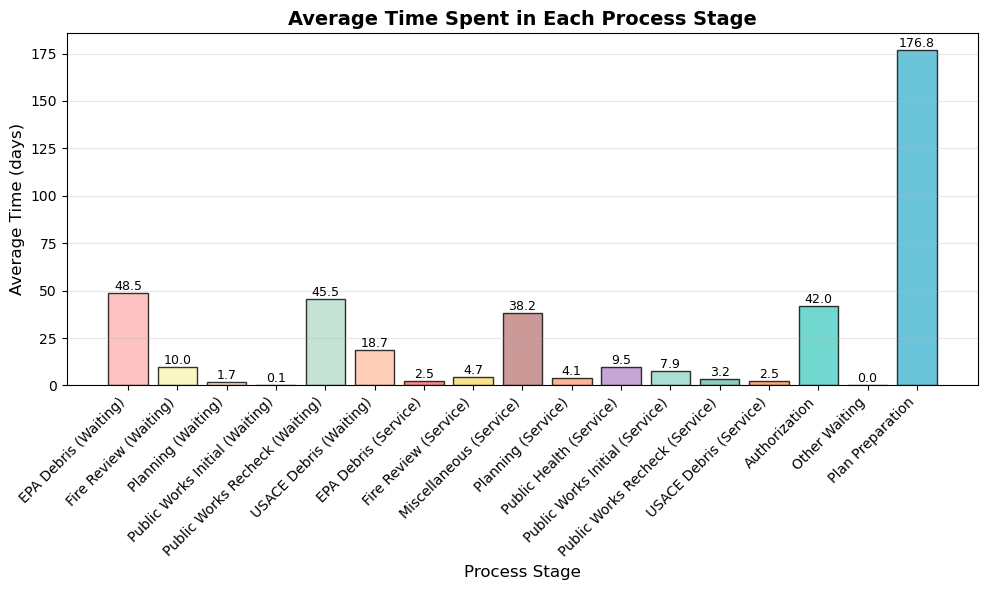

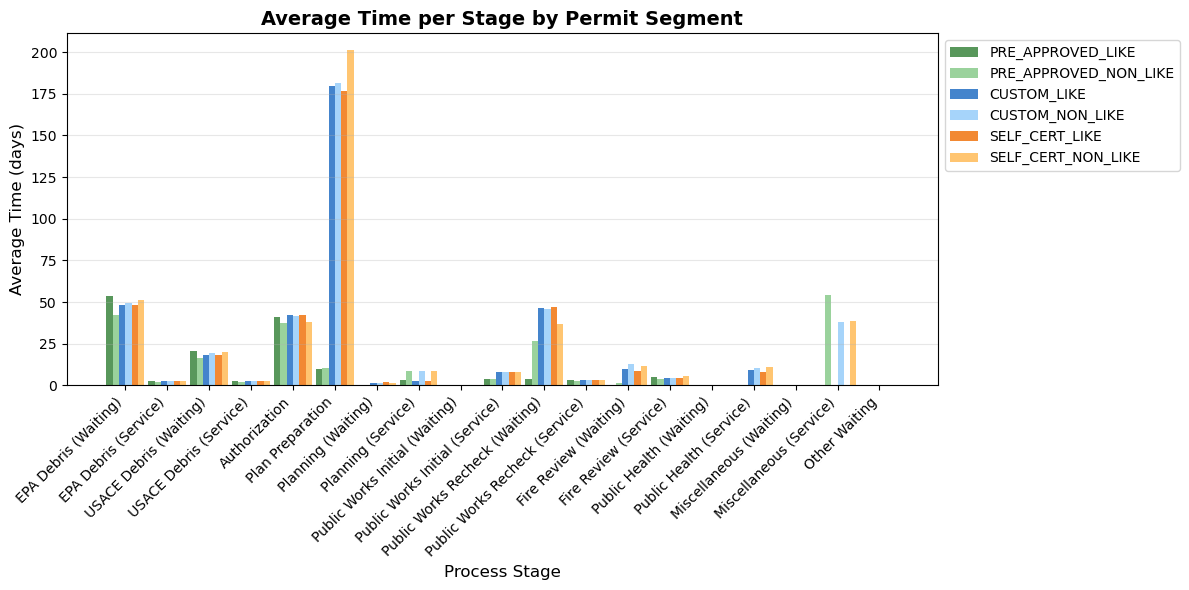

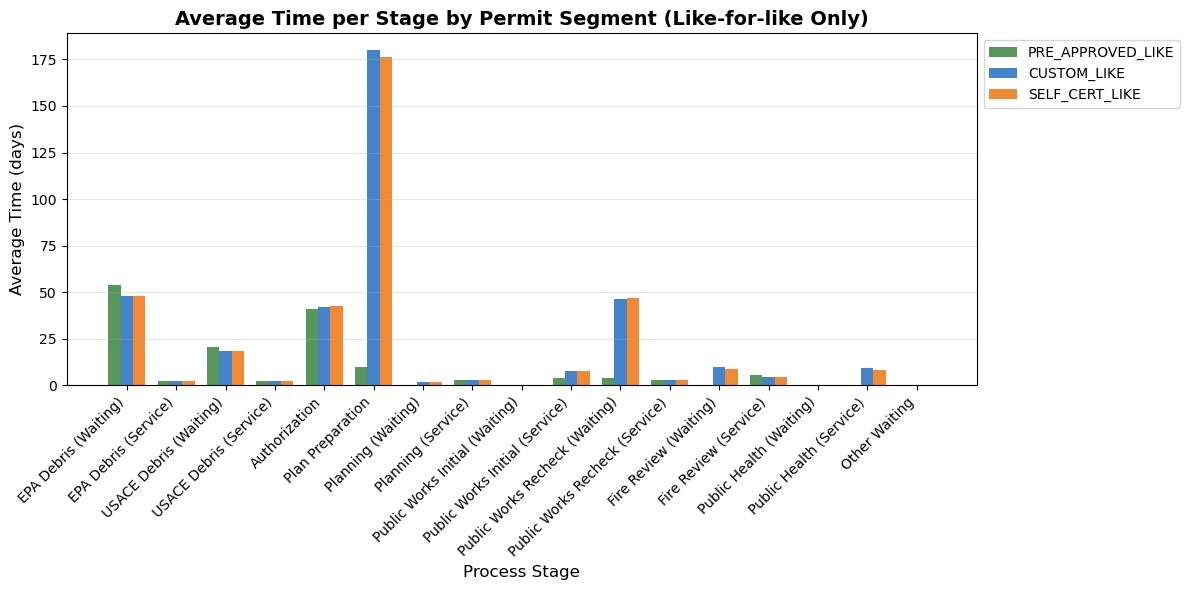

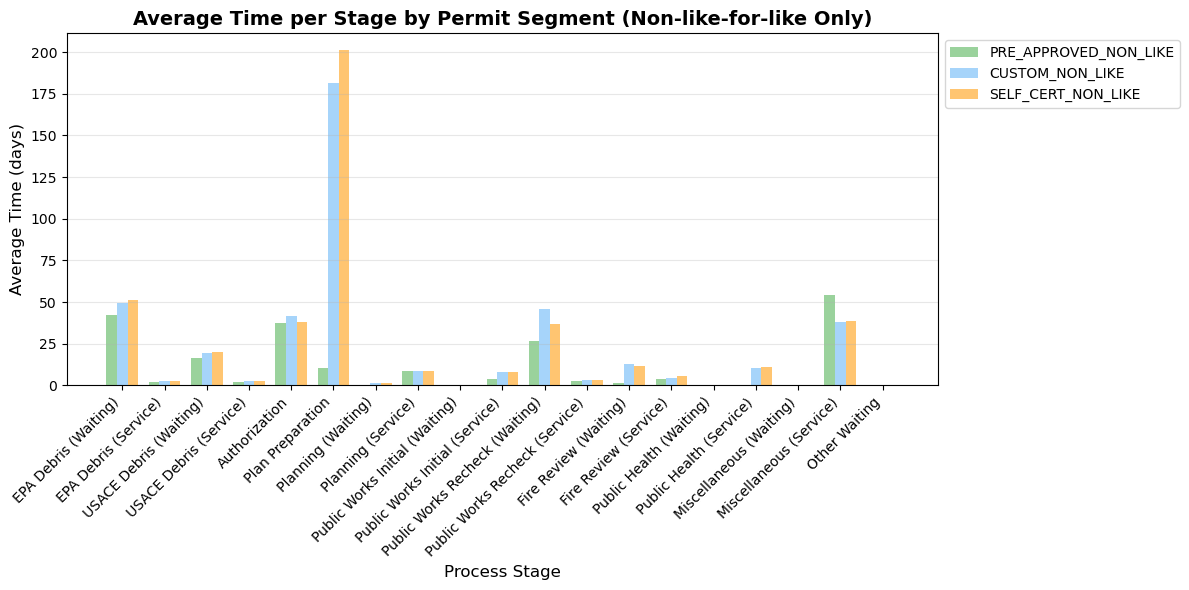

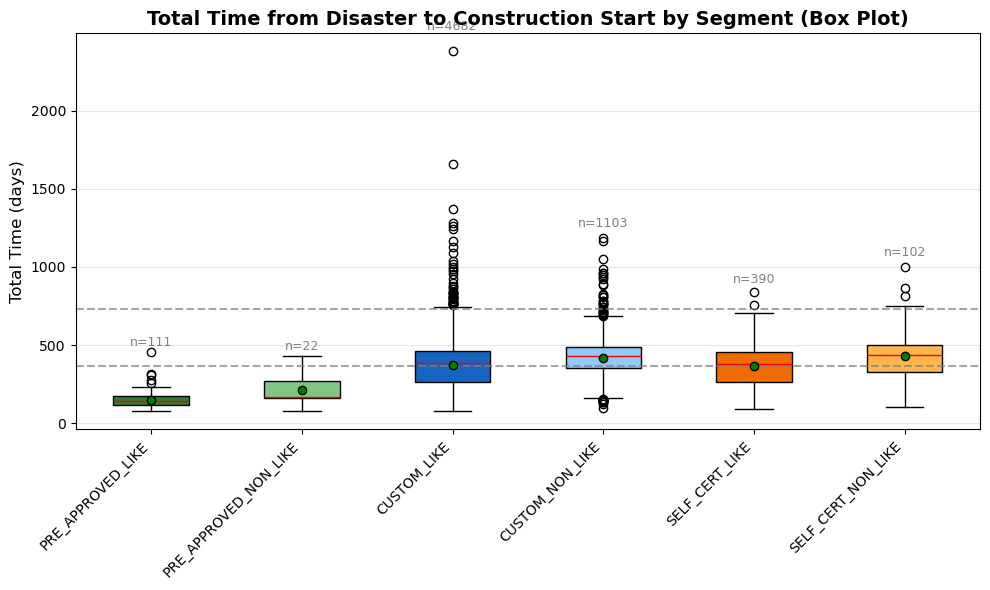

Visualizations complete!


In [3]:
# Visualize the time each permit spends in each stage
from visualize_permits import visualize_all, plot_stacked_bar_chart, plot_gantt_chart, plot_average_time_by_stage

# Create all visualizations
visualize_all(sim.completed_permits)

# Or create individual visualizations:
# plot_stacked_bar_chart(sim.completed_permits, max_permits=30)  # Stacked bar chart
# plot_gantt_chart(sim.completed_permits, max_permits=20)        # Gantt chart
# plot_average_time_by_stage(sim.completed_permits)              # Average time by stage
